# Customer Lifetime Value Prediction

## Objective
Predict customer lifetime value using retail transaction data
and segment customers based on predicted value.

## Author
Manoj

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
#from google.colab import files
#uploaded = files.upload()

In [3]:
df = pd.read_csv("/content/Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


The dataset contains transactional retail purchase data
including customer purchases, pricing, and timestamps.

In [5]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.dropna(subset=['CustomerID'], inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [6]:
import os

os.makedirs('../data/processed', exist_ok=True)
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [7]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.reset_index(inplace=True)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


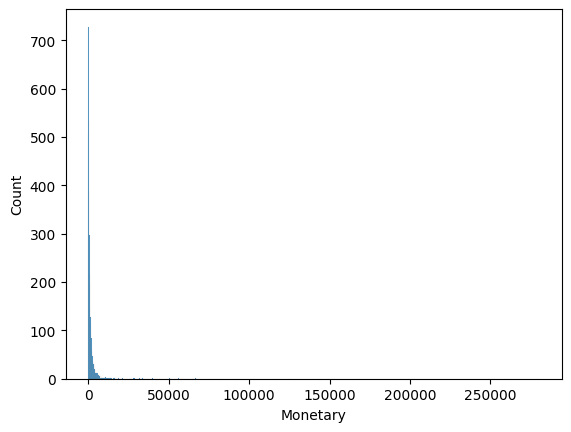

In [8]:
sns.histplot(rfm['Monetary'])
plt.show()

In [9]:
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Monetary']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

In [10]:
pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test,pred))

MAE: 32.57749129032276


In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(
    model,
    "../models/ltv_prediction_model.pkl"
)

['../models/ltv_prediction_model.pkl']

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

os.makedirs('../outputs', exist_ok=True)
importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

In [13]:
rfm['Predicted_LTV'] = model.predict(X)

In [14]:
rfm['Segment'] = pd.qcut(
    rfm['Predicted_LTV'],
    q=3,
    labels=['Low','Medium','High']
)

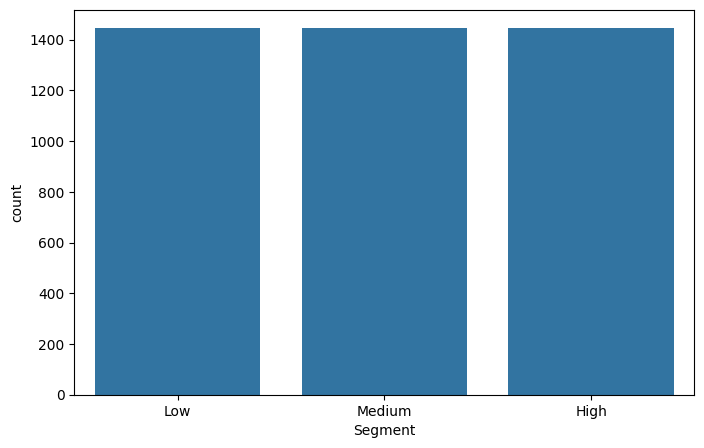

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='Segment',data=rfm)

os.makedirs('../visualizations', exist_ok=True)
plt.savefig(
    "../visualizations/segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

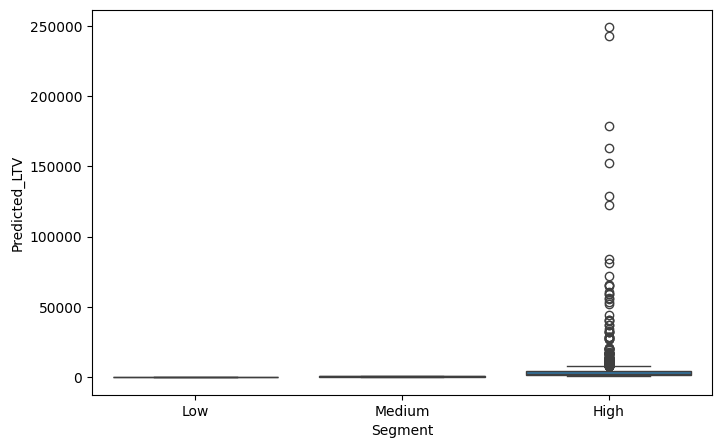

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Segment',
    y='Predicted_LTV',
    data=rfm
)

plt.savefig(
    "../visualizations/ltv_prediction_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
rfm.to_csv(
    "../outputs/customer_ltv_predictions.csv",
    index=False
)

## Key Insights
- High-value customers contribute majority revenue.
- Spending behavior strongly influences lifetime value.
- Customer segmentation supports targeted marketing.

This project demonstrates an end-to-end analytics workflow
from raw data processing to machine learning-based customer
value prediction and business insight generation.